### Обучение xgboost на различных группах признаках для предсказания победителя матча

- **Test** = последние `N_LAST_2025_TOURNAMENTS` турниров 2025 года + весь 2026 (Q1). Точный размер зависит от `matches.csv`.
- **Train** = всё остальное (2023 + 2024 + первые турниры 2025).
- Train **аугментируется swap-копией**: каждый матч добавляется ещё раз с инвертированным таргетом и зеркальными team1/team2 фичами (`src/symmetry.augment_with_swap`).
- **Константы** в коде: `N_LAST_2025_TOURNAMENTS`, `N_SEEDS`; список блоков признаков задаётся в ячейке со `blocks_files` (CSV из `data/features/`).
- Каждый сценарий обучается на `N_SEEDS` разных `random_state` (Dummy считается один раз). Ниже сводная таблица: по каждой метрике медиана и [P25, P75] по сидам.

### Группы признаков

1. **Dummy** — случайное предсказание p=0.5.
2. **Static only** — только пре-матч статические фичи (раунд, уровень турнира).
3. Для каждого блока: **Static + блок** — вклад блока поверх static.
4. **Full pre-match** — все блоки вместе (бейзлайн для Level-2).

**Метрики на одном общем тесте:** accuracy и log-loss.

**Артефакты** (см. конец ноутбука): `models/full_prematch.json`, `data/features/full_prematch_predictions_test.csv`, `data/features/baselines_raw_results.csv`.


In [17]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import accuracy_score, log_loss
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import matplotlib.pyplot as plt

REPO_ROOT = Path("../..").resolve()
sys.path.insert(0, str(REPO_ROOT))
from src.symmetry import augment_with_swap

PROCESSED = Path("../../data/processed")
FEATURES = Path("../../data/features")

N_LAST_2025_TOURNAMENTS = 5
N_SEEDS = 5

matches = pd.read_csv(PROCESSED / "matches.csv", parse_dates=["played_at"])
matches["year"] = matches["played_at"].dt.year
matches["target"] = (matches["winner"] == "team_1").astype(int)
print(f"Матчей: {len(matches)}")


Матчей: 2549


## Сбор всех блоков признаков

In [18]:
blocks_files = {
    "rolling":        FEATURES / "rolling_stats.csv",
    "elo":            FEATURES / "elo.csv",
    "pair_chemistry": FEATURES / "pair_chemistry.csv",
    "h2h":            FEATURES / "head_to_head.csv",
    "form":           FEATURES / "form_and_streaks.csv",
    "rest":           FEATURES / "rest_and_load.csv",
    "context":        FEATURES / "context.csv",
    "matchup":        FEATURES / "matchup.csv",
}

blocks = {name: pd.read_csv(p) for name, p in blocks_files.items()}
for name, b in blocks.items():
    print(f"{name:15s} : {b.shape[1] - 1:4d} фич")

rolling         :  520 фич
elo             :   18 фич
pair_chemistry  :    8 фич
h2h             :    7 фич
form            :   14 фич
rest            :   10 фич
context         :    9 фич
matchup         :    6 фич


## Static признаки

In [19]:
le = LabelEncoder()
matches["tournament_level_enc"] = le.fit_transform(matches["tournament_level"].fillna("unknown"))
STATIC_FEATURES = ["round", "tournament_level_enc"]
print(f"Static features: {STATIC_FEATURES}")

Static features: ['round', 'tournament_level_enc']


## Сборка полного датасета и энкодинг категориальных

In [20]:
data = matches[["match_id", "tournament_id", "played_at", "year", "target"] + STATIC_FEATURES].copy()

block_cols = {"static": STATIC_FEATURES}

for name, b in blocks.items():
    data = data.merge(b, on="match_id", how="left")
    block_cols[name] = [c for c in b.columns if c != "match_id"]

# Кодируем строковые категориальные
str_cols = data.select_dtypes(include="object").columns.tolist()
for c in str_cols:
    data[c] = LabelEncoder().fit_transform(data[c].astype(str).fillna("nan"))

print(f"Итого столбцов признаков: {sum(len(v) for v in block_cols.values())}")

Итого столбцов признаков: 594


## Train / Test split

Тест: последние `N_LAST_2025_TOURNAMENTS` турниров 2025 года + весь 2026

In [21]:
tour_starts = (
    data[data["year"] == 2025]
    .groupby("tournament_id")["played_at"].min()
    .sort_values()
)
last_2025_tids = tour_starts.tail(N_LAST_2025_TOURNAMENTS).index.tolist()
test_boundary = tour_starts.loc[last_2025_tids].min()
print(f"Граница test: {test_boundary.date()}")
print(f"Турниры 2025 в тесте: {len(last_2025_tids)}")

is_test = (data["tournament_id"].isin(last_2025_tids)) | (data["year"] == 2026)
train = data[~is_test].copy()
test = data[is_test].copy()
print(f"Train: {len(train):4d} строк Test: {len(test):4d} строк")
print(f"Train target mean: {train['target'].mean():.3f}; Test: {test['target'].mean():.3f}")


Граница test: 2025-10-27
Турниры 2025 в тесте: 5
Train: 2217 строк Test:  332 строк
Train target mean: 0.501; Test: 0.479


## Swap-аугментация трейна

Для каждого матча train-выборки добавляем зеркальную копию: меняем местами team_1 и team_2 во всех соответствующих фичах, инвертируем таргет

Тест НЕ трогаем

In [22]:
# Sanity: swap дважды должен возвращать исходный df
train_aug = augment_with_swap(train, binary_invert_cols=("target",))
print(f"Train исходный: {len(train)}, после swap-аугментации: {len(train_aug)}")
print(f"Доли target: исх={train['target'].mean():.3f}, после swap={train_aug['target'].mean():.3f}")

Train исходный: 2217, после swap-аугментации: 4434
Доли target: исх=0.501, после swap=0.500


In [23]:
METRICS = ["accuracy", "log_loss"]

XGB_PARAMS = dict(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss",
)


def evaluate(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "log_loss": log_loss(y_true, y_prob, labels=[0, 1]),
    }


def train_xgb(train_df, test_df, features, seed):
    model = xgb.XGBClassifier(random_state=seed, **XGB_PARAMS)
    model.fit(train_df[features], train_df["target"], verbose=False)
    prob = model.predict_proba(test_df[features])[:, 1]
    return model, prob


## Эксперимент: все сценарии × N_SEEDS

Для каждого сценария обучаемся на `train_aug` и предсказываем `test`. Повторяем `N_SEEDS` раз с разными `random_state`

In [24]:
scenarios = {"Dummy (50/50)": None, "Static only": ["static"]}
for name in blocks_files.keys():
    scenarios[f"Static + {name}"] = ["static", name]
scenarios["Full pre-match"] = ["static"] + list(blocks_files.keys())


def features_for(scenario_blocks):
    if scenario_blocks is None:
        return None
    out = []
    for b in scenario_blocks:
        out += block_cols[b]
    return out


y_test = test["target"].values
seeds = list(range(42, 42 + N_SEEDS))

raw_results = []
for name, scenario in scenarios.items():
    feats = features_for(scenario)
    for seed in seeds:
        if feats is None:
            prob = np.full(len(y_test), 0.5)
        else:
            _, prob = train_xgb(train_aug, test, feats, seed)
        m = evaluate(y_test, prob)
        m.update({"model": name, "seed": seed,
                  "n_features": 0 if feats is None else len(feats)})
        raw_results.append(m)
        if name == "Dummy (50/50)":
            break
    print(f"{name:30s} done ({0 if feats is None else len(feats):4d} фич)")

raw = pd.DataFrame(raw_results)

Dummy (50/50)                  done (   0 фич)
Static only                    done (   2 фич)
Static + rolling               done ( 522 фич)
Static + elo                   done (  20 фич)
Static + pair_chemistry        done (  10 фич)
Static + h2h                   done (   9 фич)
Static + form                  done (  16 фич)
Static + rest                  done (  12 фич)
Static + context               done (  11 фич)
Static + matchup               done (   8 фич)
Full pre-match                 done ( 594 фич)


## Результаты

In [26]:
order = list(scenarios.keys())


def fmt_series(s):
    med = s.median()
    lo, hi = s.quantile(0.25), s.quantile(0.75)
    return f"{med:.3f} [{lo:.3f}, {hi:.3f}]"


rows = []
for name in order:
    sub = raw[raw["model"] == name]
    row = {"model": name}
    for m in METRICS:
        row[m] = fmt_series(sub[m])
    rows.append(row)

summary = pd.DataFrame(rows).set_index("model")
display(summary)


,accuracy,log_loss
model,,
Dummy (50/50),"0.479 [0.479, 0.479]","0.693 [0.693, 0.693]"
Static only,"0.485 [0.482, 0.494]","0.693 [0.693, 0.693]"
Static + rolling,"0.786 [0.783, 0.786]","0.460 [0.459, 0.461]"
Static + elo,"0.795 [0.795, 0.801]","0.473 [0.471, 0.474]"
Static + pair_chemistry,"0.696 [0.693, 0.702]","0.542 [0.540, 0.542]"
Static + h2h,"0.702 [0.699, 0.720]","0.553 [0.552, 0.554]"
Static + form,"0.783 [0.783, 0.786]","0.471 [0.467, 0.474]"
Static + rest,"0.672 [0.663, 0.675]","0.614 [0.614, 0.617]"
Static + context,"0.623 [0.620, 0.627]","0.599 [0.598, 0.599]"


## Feature importance: Full pre-match (seed=42)

Full pre-match (seed=42): {'accuracy': 0.8042168674698795, 'log_loss': 0.4480827637329323}


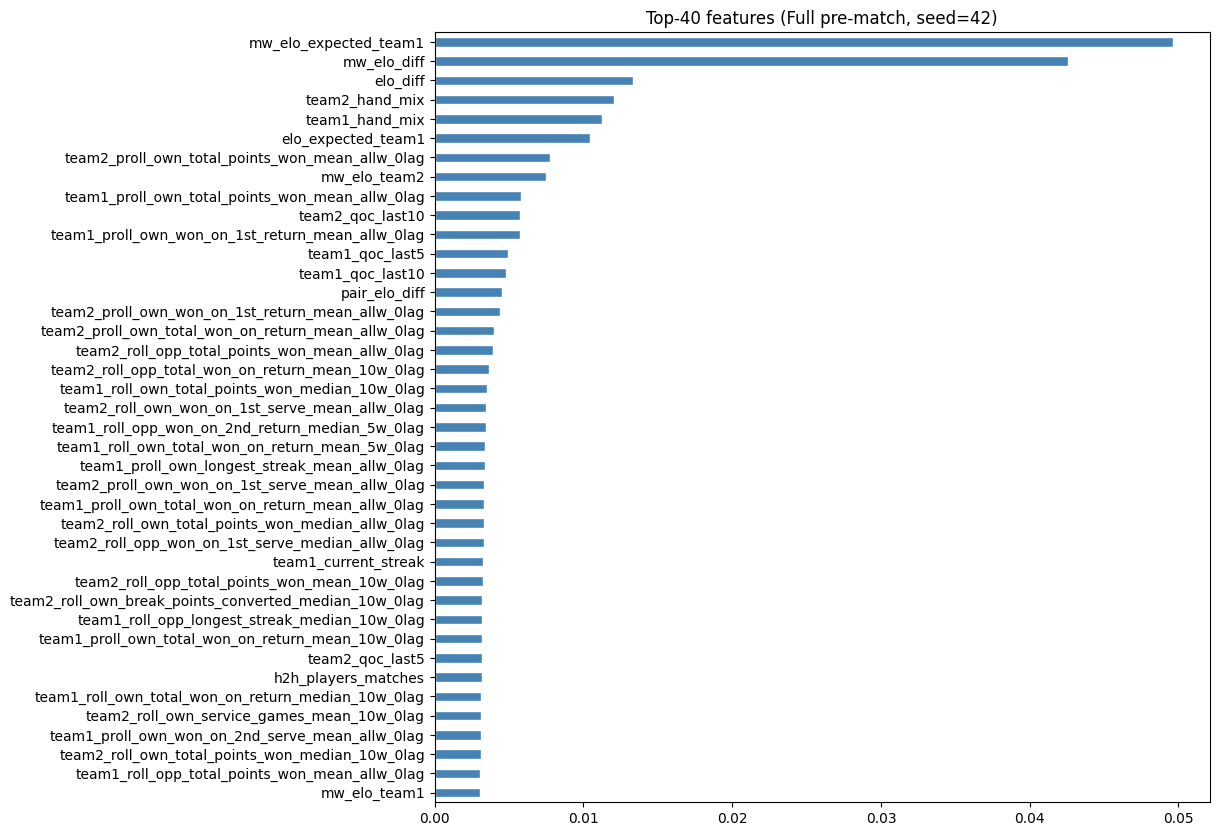

Топ-20 фич (Full pre-match, seed=42):
mw_elo_expected_team1                                 0.0496
mw_elo_diff                                           0.0426
elo_diff                                              0.0133
team2_hand_mix                                        0.0120
team1_hand_mix                                        0.0113
elo_expected_team1                                    0.0104
team2_proll_own_total_points_won_mean_allw_0lag       0.0078
mw_elo_team2                                          0.0075
team1_proll_own_total_points_won_mean_allw_0lag       0.0058
team2_qoc_last10                                      0.0058
team1_proll_own_won_on_1st_return_mean_allw_0lag      0.0057
team1_qoc_last5                                       0.0050
team1_qoc_last10                                      0.0048
pair_elo_diff                                         0.0045
team2_proll_own_won_on_1st_return_mean_allw_0lag      0.0044
team2_proll_own_total_won_on_return_mean_allw_0

In [29]:
all_features = features_for(scenarios["Full pre-match"])
model_full, prob_full = train_xgb(train_aug, test, all_features, seed=42)
print(f"Full pre-match (seed=42): {evaluate(test['target'].values, prob_full)}")

importance = pd.Series(model_full.feature_importances_, index=all_features).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 10))
importance.head(40).plot.barh(ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top-40 features (Full pre-match, seed=42)")
ax.invert_yaxis()
plt.show()

print("Топ-20 фич (Full pre-match, seed=42):")
print(importance.head(20).round(4).to_string())


## Сохранение Full модели и предсказаний

In [28]:
MODELS = Path("../../models")
MODELS.mkdir(parents=True, exist_ok=True)
model_full.save_model(MODELS / "full_prematch.json")

preds = test[["match_id"]].copy()
preds["prob_team1_full_prematch"] = prob_full
preds.to_csv(FEATURES / "full_prematch_predictions_test.csv", index=False)

raw.to_csv(FEATURES / "baselines_raw_results.csv", index=False)